# Classification & Logistic Regression: Drawing the Line

**DCS 404 · Data Science and Machine Learning**

---

Every model we have built so far answered questions of the form *how much?* How many sales from this ad
budget, what final grade for this student. The answer was always a number on a continuous scale, and the
machinery — a line, a cost function, gradient descent, a regularization penalty — was built around that.

Today the question changes shape: *which one?* Does this student get admitted or not? Does this patient
have diabetes or not? Is this handwritten digit a 3, a 5, or an 8? These are **classification** problems,
and they are arguably the most common kind of problem in applied machine learning — spam filters, fraud
detection, medical screening, image recognition are all classification at heart.

Our tool for the day is **logistic regression** — which, despite the name, is a *classifier*. The name is
an accident of history: it really is our old friend linear regression, wearing one extra piece of clothing
(a squashing function called the *sigmoid*) that turns its unbounded output into a probability. Almost
everything you learned in the last three modules — cost functions, convexity, gradient descent, feature
scaling, train/test splits — transfers directly. That is the quiet theme of this module: *you already know
most of this; we are just pointing it at a new kind of question.*

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in three acts:

1. **Sections 1–5** build intuition on a tiny synthetic dataset (20 students, GRE scores, admit or reject)
   — small enough that you can see every data point and every decision the model makes.
2. **Sections 6–7** open the hood: what cost function does logistic regression minimize, and why does
   gradient descent — the very algorithm from the Gradient Descent module — still work?
3. **Sections 8–10** go real: a diabetes-screening dataset with 768 patients, the metrics you need to judge
   a classifier honestly (accuracy will try to lie to you), and what to do when there are more than two classes.

## Learning objectives

After completing this module you will be able to:

- Distinguish **classification** from regression and explain why fitting a straight line to 0/1 labels fails.
- Define the **sigmoid function**, list its key properties, and explain how it turns a linear model's output
  into a probability.
- Fit `LogisticRegression` in scikit-learn; obtain class labels with `predict` and probabilities with
  `predict_proba`; interpret a **decision boundary**.
- Explain why sum-of-squared-errors is the wrong cost for classification, and write down the
  **binary cross-entropy (BCE)** cost function.
- Derive (or at least follow the derivation of) the BCE gradient and recognize that the gradient-descent
  update rule is *identical in form* to linear regression's.
- Evaluate a classifier with a **confusion matrix**, **accuracy**, **precision**, **recall**, and **F1 score**
  — and explain the *accuracy paradox* on imbalanced data.
- Describe three strategies for **multiclass** problems: One-vs-Rest, One-vs-One, and **softmax** regression
  with the cross-entropy cost.

## Setup

Run this once. Libraries, the usual plotting style, and the diabetes dataset (which we'll need in Section 8).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score, classification_report)

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42

# Load the Pima Indians Diabetes dataset (used in Section 8)
for candidate in [Path("data/diabetes.csv"),
                  Path("notebooks/data/diabetes.csv")]:
    if candidate.exists():
        diabetes = pd.read_csv(candidate)
        print(f"Loaded diabetes dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find diabetes.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {diabetes.shape[0]} patients, {diabetes.shape[1]} columns")

Loaded diabetes dataset from: data/diabetes.csv
Shape: 768 patients, 9 columns


---
## 1. A new kind of question

In regression we predicted a **continuous** value: a grade between 0 and 20, sales in thousands of units.
In **classification** we predict a **discrete** label from a fixed menu of choices. Two flavours:

- **Binary classification** — exactly two classes. Spam / not spam. Diabetic / not diabetic. We
  conventionally call them the **positive class** ($y = 1$) and the **negative class** ($y = 0$).
- **Multiclass classification** — more than two. Which of ten digits? Which of three iris species?

<div align="center">
<table><tr>
<td><img src="resources/images/binary_classification.png" width="360"></td>
<td><img src="resources/images/multiclass_classification.png" width="360"></td>
</tr></table>

*Figure 1 — Left: two classes, separable by a single boundary. Right: three classes — we'll need more
machinery for this (Section 10).*
</div>

We start with the binary case, on a dataset small enough to inspect by eye: **20 students, one feature
(GRE score), one label (admitted to a university or not)**. Here $y = 1$ means admitted, $y = 0$ means
rejected. We generate it synthetically with scikit-learn's `make_classification`, so we control exactly
how the two classes overlap.

In [2]:
def generate_dataset():
    """20 students: GRE score vs. admission (1 = admitted, 0 = rejected)."""
    features, labels = make_classification(
        n_samples=20, n_features=1, n_informative=1, n_redundant=0, n_repeated=0,
        n_classes=2, n_clusters_per_class=1, class_sep=1,
        shift=30, scale=10, random_state=1)
    df = pd.DataFrame(np.ceil(features).astype(int), columns=["GRE_Score"])
    df["Admission"] = labels
    return df

students = generate_dataset()
students.head()

,GRE_Score,Admission
0,310,1
1,297,0
2,318,1
3,290,0
4,288,0


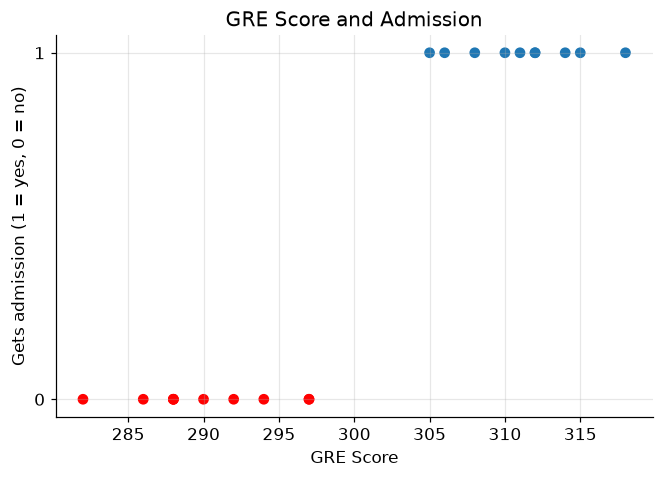

In [3]:
map_color = np.array(["red", "tab:blue"])

x = students[["GRE_Score"]].values   # feature matrix (20, 1)
y = students["Admission"].values     # labels (20,)

plt.scatter(students.GRE_Score, students.Admission, c=map_color[y])
plt.title("GRE Score and Admission")
plt.xlabel("GRE Score")
plt.ylabel("Gets admission (1 = yes, 0 = no)")
plt.yticks([0, 1])
plt.show()

Pause on this plot, because it looks *nothing* like the scatter plots from the Regression module. There is
no upward or downward drift of points to chase with a line — every point sits on one of exactly two shelves,
$y = 0$ or $y = 1$. Higher GRE scores are clearly bluer (admitted) and lower scores redder (rejected), so
there *is* signal here. The question is what kind of model can capture it.

---
## 2. The obvious idea, and why it fails

We own a hammer — linear regression — so let's swing it. Fit a straight line to these 0/1 labels and see
what happens.

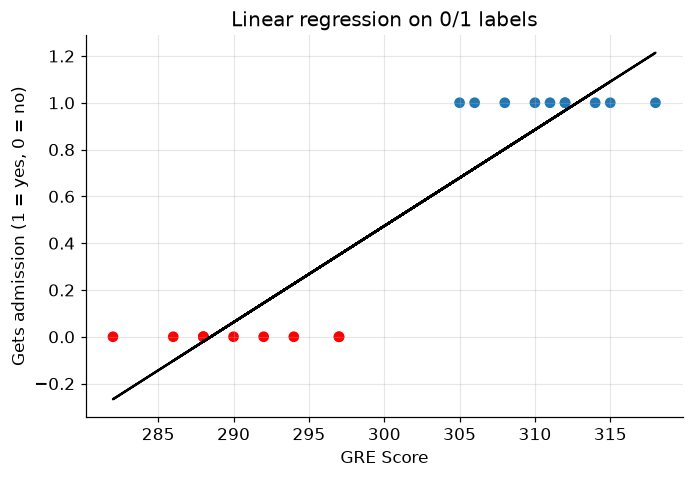

In [4]:
linear_regressor = LinearRegression()
linear_regressor.fit(x, y)

plt.scatter(x, y, c=map_color[y])
plt.plot(x, linear_regressor.predict(x), color="black")
plt.title("Linear regression on 0/1 labels")
plt.xlabel("GRE Score")
plt.ylabel("Gets admission (1 = yes, 0 = no)")
plt.show()

The line dutifully minimizes squared error, but as a *classifier* it is a mess:

1. **It predicts impossible values.** A student with a very high GRE gets a prediction above 1; a very low
   GRE gets a prediction *below 0*. What would an admission probability of $-0.3$ or $1.4$ even mean? We
   want outputs pinned to $[0, 1]$.
2. **It barely fits the data.** A good regression line passes near most points; this one passes near almost
   none, because the data simply isn't linear — it's two flat shelves with a jump between them.
3. **It is fragile.** (Try it yourself in Exercise 1.) Add one admitted student with an extremely high GRE
   score and the whole line tilts, dragging the effective cutoff with it — one easy, unambiguous example
   should not change our mind about the borderline cases.

What we actually want is a curve that hugs 0 on the left, hugs 1 on the right, and transitions smoothly
in between — something shaped like a stretched-out letter **S**. Mathematics has exactly the function.

---
## 3. The sigmoid function

Recall the equation of simple linear regression:

$$\hat{y} = \beta_0 + \beta_1 x$$

Its output $\hat y$ ranges over all real numbers — that was problem 1 above. **Logistic regression keeps the
linear part but passes its output through the *sigmoid function***, defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z$ is any real number.

<div align="center">
<img src="resources/images/sigmoid_function.png" width="440">

*Figure 2 — The sigmoid (logistic) function: an S-shaped curve that squashes the whole real line into (0, 1).*
</div>

Let's plot it ourselves and read off its properties.

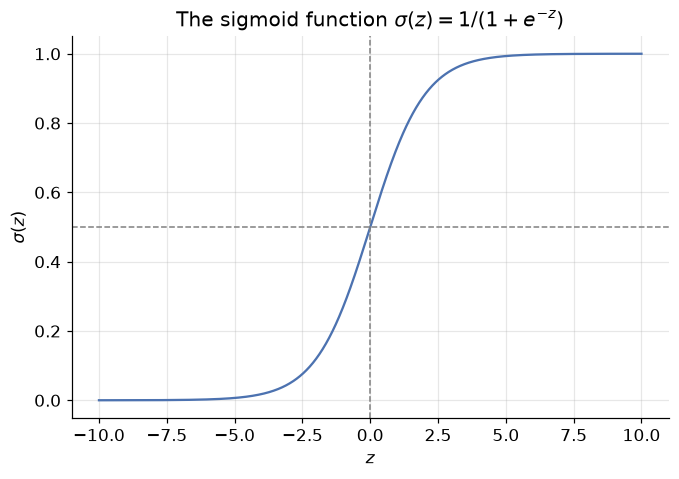

In [5]:
z = np.linspace(-10, 10, 1000)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

plt.plot(z, sigmoid(z))
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("The sigmoid function $\\sigma(z) = 1/(1+e^{-z})$")
plt.xlabel("$z$")
plt.ylabel("$\\sigma(z)$")
plt.show()

Three properties do all the work:

- **Squashing:** whatever real number $z$ you feed in, $\sigma(z)$ lands strictly between 0 and 1 — so the
  output can always be read as a *probability*.
- **Midpoint:** $\sigma(0) = 0.5$. The input $z = 0$ is the "perfectly unsure" point.
- **Saturation:** large positive $z$ gives $\sigma(z) \approx 1$ (confident *yes*); large negative $z$ gives
  $\sigma(z) \approx 0$ (confident *no*).

**The logistic regression model** is then: compute the linear score, squash it. Writing $p(x)$ for the
model's output on input $x$:

$$p(x) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

and we interpret

$$p(x) = \text{estimated probability that } y = 1 \text{ given } x, \qquad 1 - p(x) = \text{probability that } y = 0.$$

To turn a probability into a hard class label, apply a threshold — by default, predict class 1 whenever
$p(x) \geq 0.5$, which is precisely where the linear score $\beta_0 + \beta_1 x$ crosses zero.

The coefficients $\beta_0, \beta_1$ must be *learned from data*, exactly as in linear regression — we'll see
how in Sections 6–7. First, let's just use it.

---
## 4. Fitting logistic regression with scikit-learn

Scikit-learn's API is deliberately uniform: swap `LinearRegression` for `LogisticRegression`, and the
`fit` / `predict` workflow is unchanged.

In [6]:
logistic_regression = LogisticRegression()
logistic_regression.fit(x, y)

print(f"Learned coefficients:  beta_0 (intercept) = {logistic_regression.intercept_[0]:.3f}, "
      f"beta_1 (slope) = {logistic_regression.coef_[0][0]:.3f}")

Learned coefficients:  beta_0 (intercept) = -228.815, beta_1 (slope) = 0.760


### Two students walk into the admissions office

Meet **Jacob** (GRE score 304) and **Lacy** (GRE score 299). The fitted model can give us two kinds of
answers about them.

**Hard labels** come from `predict` — it applies the 0.5 threshold for us:

In [7]:
class_label_jacob = logistic_regression.predict([[304]])
print("Predicted class for Jacob (GRE 304):", class_label_jacob[0])

class_label_lacy = logistic_regression.predict([[299]])
print("Predicted class for Lacy  (GRE 299):", class_label_lacy[0])

Predicted class for Jacob (GRE 304): 1
Predicted class for Lacy  (GRE 299): 0


Jacob is predicted admitted (1), Lacy rejected (0). But hard labels hide how *confident* the model is —
a 51% call and a 99% call print the same "1". For the full story, `predict_proba` returns both class
probabilities: column 0 is $P(y=0)$, column 1 is $P(y=1)$, and each row sums to 1.

In [8]:
for name, gre in [("Jacob", 304), ("Lacy", 299)]:
    p_reject, p_admit = logistic_regression.predict_proba([[gre]])[0]
    print(f"{name} (GRE {gre}):  P(rejected) = {p_reject:.4f},  P(admitted) = {p_admit:.4f}")

Jacob (GRE 304):  P(rejected) = 0.1054,  P(admitted) = 0.8946
Lacy (GRE 299):  P(rejected) = 0.8402,  P(admitted) = 0.1598


This is the practical superpower of logistic regression over many other classifiers: it doesn't just vote,
it tells you *how sure it is* — and in domains like medicine or credit scoring, that calibrated probability
is often worth more than the label itself.

Let's see the whole fitted curve at once: the S-shape laid over our 20 students, with the 0.5 threshold
marked.

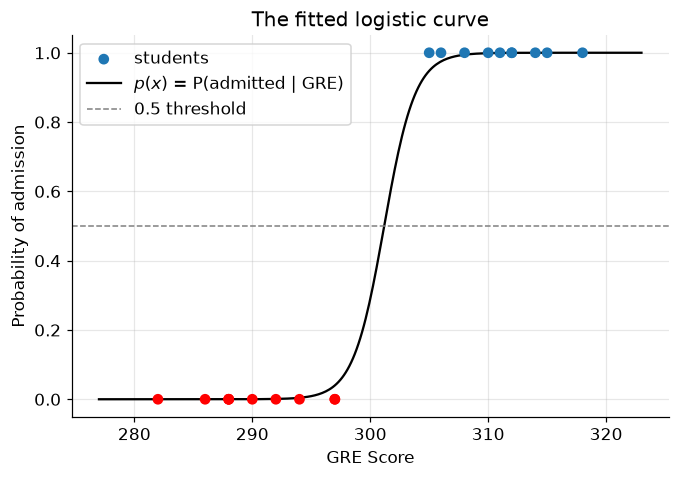

In [9]:
gre_grid = np.linspace(x.min() - 5, x.max() + 5, 300).reshape(-1, 1)
p_admit = logistic_regression.predict_proba(gre_grid)[:, 1]

plt.scatter(x, y, c=map_color[y], zorder=3, label="students")
plt.plot(gre_grid, p_admit, color="black", label="$p(x)$ = P(admitted | GRE)")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="0.5 threshold")
plt.title("The fitted logistic curve")
plt.xlabel("GRE Score")
plt.ylabel("Probability of admission")
plt.legend()
plt.show()

Compare this with the straight line from Section 2. The sigmoid hugs the two shelves of data, never leaves
$[0, 1]$, and crosses 0.5 right in the overlap zone where the reds and blues mix — exactly where an honest
model *should* be uncertain. The GRE score where the curve crosses 0.5 is the model's cutoff: that single
point is the **decision boundary** in one dimension.

---
## 5. The decision boundary

**The decision boundary is the surface that separates the region where the model predicts $y=0$ from the
region where it predicts $y=1$** — all the points where $p(x)$ is exactly 0.5. With one feature it's a
point; with two features it's a line; in higher dimensions, a (hyper)plane.

Two features is where visualization gets interesting, so let's give our admissions committee a second
signal: each student's **CGPA** alongside their GRE score.

In [10]:
def generate_dataset_2d():
    """20 students: GRE score and CGPA vs. admission."""
    features, labels = make_classification(
        n_samples=20, n_features=2, n_informative=2, n_redundant=0, n_repeated=0,
        n_classes=2, n_clusters_per_class=1, class_sep=0.9,
        shift=[31, 2.6], scale=[10, 3], random_state=10)
    df = pd.DataFrame(features, columns=["GRE_Score", "CGPA"])
    df["GRE_Score"] = np.ceil(df["GRE_Score"]).astype(int)
    df["CGPA"] = df["CGPA"].round(1)
    df["Admission"] = np.where(labels > 0.5, 0, 1)  # flip so blue = admitted, as before
    return df

students_2d = generate_dataset_2d()
students_2d.head()

,GRE_Score,CGPA,Admission
0,313,7.2,1
1,312,7.5,1
2,295,3.3,0
3,325,3.3,1
4,299,4.0,0


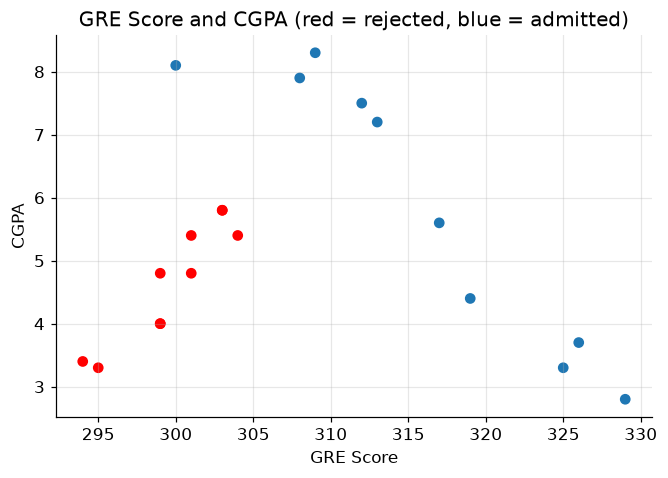

In [11]:
X = students_2d[["GRE_Score", "CGPA"]].values
y2 = students_2d["Admission"].values

plt.scatter(students_2d.GRE_Score, students_2d.CGPA, c=map_color[y2])
plt.title("GRE Score and CGPA (red = rejected, blue = admitted)")
plt.xlabel("GRE Score")
plt.ylabel("CGPA")
plt.show()

Now each student is a point in a 2-D plane, coloured by outcome. Fitting logistic regression is one line of
code; the rest of the cell below just colours every point of the plane by the model's prediction, so the
boundary between the two coloured regions *is* the decision boundary.

*Don't worry about the meshgrid plotting code — it's scaffolding, not the lesson. All you need to take from
it is the picture.*

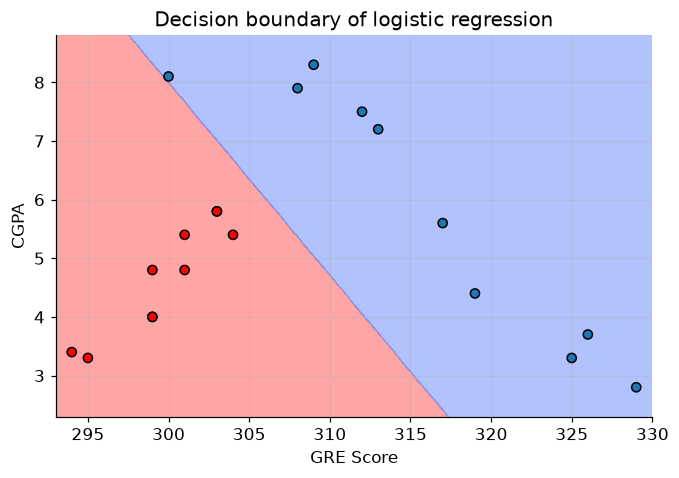

In [12]:
from matplotlib.colors import ListedColormap

logistic_2d = LogisticRegression()
logistic_2d.fit(X, y2)

# Build a fine grid covering the feature space
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                       np.arange(x2_min, x2_max, 0.02))

# Ask the model to classify every grid point, then colour the regions
grid_labels = logistic_2d.predict(np.c_[xx1.ravel(), xx2.ravel()])
plt.contourf(xx1, xx2, grid_labels.reshape(xx1.shape),
             alpha=0.6, cmap=ListedColormap(["#FE6969", "#7F9AFD"]))

plt.scatter(X[:, 0], X[:, 1], c=map_color[y2], edgecolor="black", zorder=3)
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min + 0.5, x2_max - 0.5)
plt.title("Decision boundary of logistic regression")
plt.xlabel("GRE Score")
plt.ylabel("CGPA")
plt.show()

The straight line where red region meets blue region is the decision boundary: on one side the model says
"rejected", on the other "admitted". Notice it is *not* vertical — the model has learned to trade GRE
against CGPA, so a student with a modest GRE but a strong CGPA can still land on the blue side.

Note that logistic regression's boundary is always **linear** in the features (a consequence of the linear
score $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2$ inside the sigmoid). A couple of points sit on the wrong
side — with overlapping classes, no straight line can be perfect, and chasing those points would be the
classification version of the overfitting we met in the Regularization module.

---
## 6. What is `fit` actually minimizing?

`fit` felt like magic, so let's open the hood — the same move we made for linear regression. Training means
choosing parameters $w$ (the $\beta$'s) that make the model's probabilities match the labels. That requires
a **cost function** to minimize. We already own one: the mean squared error from linear regression,

$$\mathcal{J}(w) = \frac{1}{m} \sum_{i=1}^m \frac{1}{2} \left(h_w(x^{(i)}) - y^{(i)}\right)^2$$

where $h_w(x) = \sigma(w^T x)$ is our model. Why not reuse it?

**Because the sigmoid breaks its convexity.** With the sigmoid nested inside the square, the cost surface
develops flat plateaus and multiple dips. Gradient descent on such a surface can settle into a local
minimum and stop, far from the best parameters — the exact hazard we saw in the Gradient Descent module.

<div align="center">
<table><tr>
<td><img src="resources/images/convex_cost_lr.png" width="360"></td>
<td><img src="resources/images/nonconvex_cost_lr.png" width="360"></td>
</tr></table>

*Figure 3 — Left: a convex cost — one global minimum, gradient descent always finds it. Right: non-convex —
which valley you land in depends on where you start.*
</div>

So we need a cost function that (a) rewards confident-and-correct probabilities, punishes
confident-and-wrong ones, and (b) stays convex. Here is the one that works, defined case by case:

$$
\text{Cost}(h_w(x), y) =
\begin{cases}
  -\log(h_w(x)) & \text{if } y = 1 \\
  -\log(1 - h_w(x)) & \text{if } y = 0
\end{cases}
\tag{Equation 1}
$$

<div align="center">
<img src="resources/images/bce_cost_behavior.png" width="640">

*Figure 4 — The cost as a function of the predicted probability $h_w(x)$, for a positive example (left)
and a negative example (right).*
</div>

Read the left panel (a truly admitted student, $y=1$): predict $h_w(x) \approx 1$ and the cost is
$-\log(1) = 0$ — no penalty for being right. Predict $h_w(x) \to 0$ — confidently wrong — and the cost
blows up toward infinity. The right panel mirrors this for $y = 0$. **The logarithm is what makes
overconfidence in the wrong direction catastrophically expensive**, which is exactly the incentive we want
to give the model.

### One formula instead of two cases

A neat algebraic trick collapses the two cases into a single line:

$$\text{Cost}(h_w(x), y) = -y \log(h_w(x)) - (1-y)\log(1 - h_w(x)) \tag{Equation 2}$$

Check it: if $y = 1$ the second term vanishes, leaving $-\log(h_w(x))$; if $y = 0$ the first term vanishes,
leaving $-\log(1 - h_w(x))$. Same behaviour, no cases — and now we can differentiate it.

### Binary cross-entropy

Averaging Equation 2 over all $m$ training examples gives the full cost function, known as the
**binary cross-entropy (BCE)**, or *log loss*:

$$\mathcal{J}(w) = -\frac{1}{m} \sum_{i=1}^m \Big[ y_i \log\big(\sigma(w^T x_i)\big) + (1 - y_i) \log\big(1 - \sigma(w^T x_i)\big) \Big] \tag{Equation 3}$$

Two facts about Equation 3 shape everything that follows:

- **No closed-form solution.** Unlike linear regression's normal equation, no formula hands us the optimal
  $w$. We *must* optimize iteratively.
- **It is convex.** One global minimum, no traps — so gradient descent, with a sensible learning rate,
  is guaranteed to find the best parameters.

You know what comes next.

---
## 7. Gradient descent, again (and a small miracle)

To run gradient descent we need $\partial \mathcal{J} / \partial w_j$ — how the cost changes as we nudge
each weight. The derivation is a chain-rule exercise in three links (cost → sigmoid output → linear score →
weight). Follow it once with a pencil; here is the skeleton for a single example, with
$a = \sigma(z)$ and $z = w^T x$:

$$
\frac{\partial \mathcal{J}}{\partial w_j}
= \frac{\partial \mathcal{J}}{\partial a}
\cdot \frac{\partial a}{\partial z}
\cdot \frac{\partial z}{\partial w_j}
= \underbrace{\frac{a - y}{a(1-a)}}_{\text{from the logs}}
\cdot \underbrace{a(1-a)}_{\text{sigmoid's derivative}}
\cdot \underbrace{x_j}_{\text{linear part}}
$$

The $a(1-a)$ factors cancel — that is the small miracle. (The sigmoid's tidy derivative,
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, is no accident; it's one reason this particular S-curve was chosen.)
Averaged over $m$ examples:

$$\frac{\partial \mathcal{J}(w)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^m \big(\sigma(w^T x_i) - y_i\big)\, x_i^{(j)}$$

Look closely: this is **(prediction − truth) × feature, averaged** — *the exact same form as the linear
regression gradient* from the Gradient Descent module. The cost function changed completely (squared error
→ cross-entropy), the model changed (line → sigmoid), and yet the update rule survives untouched:

$$w_j \leftarrow w_j - \alpha \frac{\partial \mathcal{J}(w)}{\partial w_j} \tag{Equation 4}$$

Seeing is believing — let's train logistic regression *from scratch* in a dozen lines and check it against
scikit-learn. Two small preparations, both callbacks to earlier modules:

- As in the Gradient Descent module, we **standardize** the feature first, so one learning rate suits
  both weights.
- Scikit-learn's `LogisticRegression` quietly applies **L2 regularization by default** — the ridge penalty
  from the Regularization module, with strength $1/C$ (default $C = 1$). To compare apples to apples, we
  add the same small penalty term to our gradient. (There's a deeper reason it's on by default: on a
  cleanly separable dataset like ours, *unregularized* BCE can always be improved by making the weights
  bigger — the S-curve just gets ever steeper — so the weights would grow forever. The ridge penalty gives
  the optimization a finite, unique answer.)

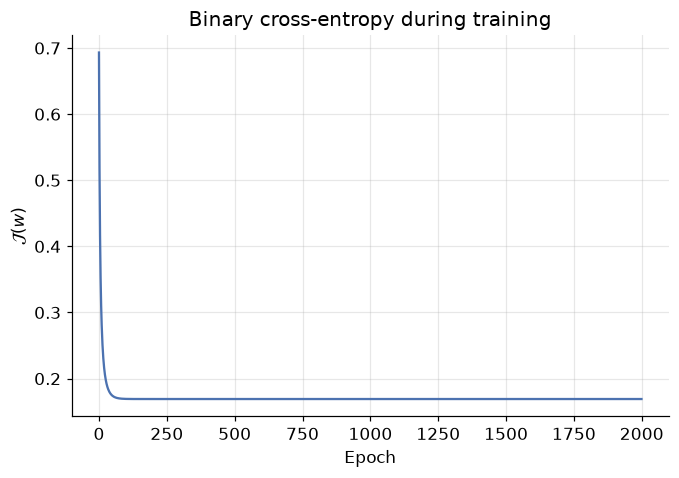

From scratch:  beta_0 = -0.0355,  beta_1 = 2.0934


In [13]:
# ── Logistic regression from scratch, on the GRE data ──────────────────
scaler_gre = StandardScaler()
x_scaled = scaler_gre.fit_transform(x)          # standardized GRE scores
X_design = np.c_[np.ones(len(x_scaled)), x_scaled]  # prepend a column of 1s for the intercept

m = len(y)
w = np.zeros(2)          # [beta_0, beta_1] — start at zero
alpha = 0.5              # learning rate
C = 1.0                  # inverse regularization strength (sklearn's default)
costs = []

for epoch in range(2000):
    p = sigmoid(X_design @ w)                        # current predicted probabilities
    gradient = X_design.T @ (p - y) / m              # (prediction - truth) x feature, averaged
    gradient[1:] += w[1:] / (C * m)                  # ridge penalty (not on the intercept)
    w -= alpha * gradient                            # Equation 4
    eps = 1e-12                                      # keep log() away from 0
    costs.append(-np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))

plt.plot(costs)
plt.title("Binary cross-entropy during training")
plt.xlabel("Epoch")
plt.ylabel("$\\mathcal{J}(w)$")
plt.show()

print(f"From scratch:  beta_0 = {w[0]:.4f},  beta_1 = {w[1]:.4f}")

In [14]:
# Sanity check against scikit-learn on the same standardized feature
sk_check = LogisticRegression().fit(x_scaled, y)
print(f"scikit-learn:  beta_0 = {sk_check.intercept_[0]:.4f},  beta_1 = {sk_check.coef_[0][0]:.4f}")

ours = (sigmoid(X_design @ w) >= 0.5).astype(int)
print(f"\nAgreement with sklearn's predictions: {np.mean(ours == sk_check.predict(x_scaled)):.0%}")

scikit-learn:  beta_0 = -0.0354,  beta_1 = 2.0931

Agreement with sklearn's predictions: 100%


The cost falls smoothly to a floor (convexity at work — no bouncing between valleys), our hand-rolled
coefficients land on top of scikit-learn's to four decimal places, and the two models agree on every
student. Everything you learned about gradient descent — learning rates, epochs, feature scaling,
convergence — transferred wholesale. `fit` is not magic; it's Equation 4 in a loop.

---
## 8. Real data: screening for diabetes

Twenty synthetic students were good for intuition; time for the real world. The **Pima Indians Diabetes
Dataset** contains diagnostic measurements for **768 female patients** of Pima Indian heritage, aged 21+,
collected by the US National Institute of Diabetes and Digestive and Kidney Diseases. The task: predict
from eight measurements whether a patient has diabetes.

| Feature | Meaning |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skin fold thickness (mm) |
| `Insulin` | 2-hour serum insulin (mu U/ml) |
| `BMI` | Body mass index (kg/m²) |
| `DiabetesPedigreeFunction` | A score of diabetes likelihood based on family history |
| `Age` | Age in years |
| `Outcome` | **Label:** 1 = has diabetes, 0 = does not |

We loaded it in the Setup cell; let's look at it.

In [15]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
diabetes.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Two things to notice in `describe()`:

- **Wildly different scales.** `DiabetesPedigreeFunction` lives between 0.08 and 2.42 while `Glucose` runs
  0 to 199. We know from the Gradient Descent module what mismatched scales do to optimization — so we'll
  standardize with `StandardScaler`.
- **Suspicious zeros.** A minimum blood pressure or BMI of 0 is not biology, it's a missing value recorded
  as 0. A production analysis would treat those properly (Exercise 4 asks you to); today we focus on the
  classification workflow.

The pipeline is the one you know from the ML Workflow module — split first, then scale (fitting the scaler
on training data only, to avoid leaking test-set information), then fit:

In [17]:
X_diab = diabetes.drop("Outcome", axis=1)
y_diab = diabetes["Outcome"]

# 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=RANDOM_STATE)

# Standardize: fit on train only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logistic_diab = LogisticRegression()
logistic_diab.fit(X_train, y_train)

y_pred = logistic_diab.predict(X_test)
print(f"Trained on {len(y_train)} patients; predicted outcomes for {len(y_test)} held-out patients.")

Trained on 537 patients; predicted outcomes for 231 held-out patients.


---
## 9. How good is this classifier, really?

For regression we had RMSE and $R^2$. Classification needs its own toolkit — and choosing the *wrong* metric
here isn't a technicality, it can make a dangerous model look excellent. Everything starts from one table.

### 9.1 The confusion matrix

Cross the two things that can be true (actual class) with the two things the model can say (predicted
class) and you get four outcomes:

<div align="center">
<img src="resources/images/confusion_matrix.png" width="380">

*Figure 5 — The confusion matrix. Rows: actual class. Columns: predicted class.*
</div>

- **TN (True Negative)** — model said 0, truth was 0. Correct.
- **TP (True Positive)** — model said 1, truth was 1. Correct.
- **FP (False Positive)** — model said 1, truth was 0. A false alarm — also called **Type I error**.
- **FN (False Negative)** — model said 0, truth was 1. A miss — also called **Type II error**.

The diagonal holds the successes; the off-diagonal holds the two different *kinds* of mistake. Keeping FP
and FN separate is the entire point — in a medical screening problem they are nowhere near equally bad, as
we'll see.

TN = 120   correctly told they don't have diabetes
FP =  31   healthy patients flagged as diabetic (false alarm, Type I)
FN =  30   diabetic patients sent home undetected (miss, Type II)
TP =  50   correctly diagnosed with diabetes


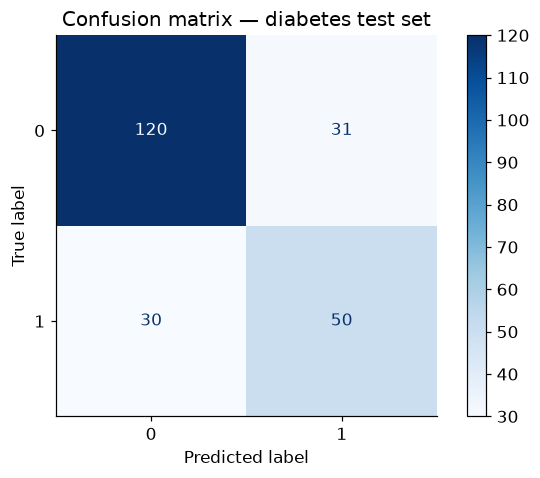

In [18]:
matrix = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = matrix.ravel()
print(f"TN = {tn:3d}   correctly told they don't have diabetes")
print(f"FP = {fp:3d}   healthy patients flagged as diabetic (false alarm, Type I)")
print(f"FN = {fn:3d}   diabetic patients sent home undetected (miss, Type II)")
print(f"TP = {tp:3d}   correctly diagnosed with diabetes")

ConfusionMatrixDisplay.from_estimator(logistic_diab, X_test, y_test, cmap="Blues")
plt.title("Confusion matrix — diabetes test set")
plt.grid(False)
plt.show()

Keep those four numbers in view — every metric below is just a different ratio of them, each answering a
different question.

### 9.2 Accuracy — "how often is it right?"

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{all predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  →  the model classifies {accuracy:.1%} of held-out patients correctly")

Accuracy: 0.7359  →  the model classifies 73.6% of held-out patients correctly


Respectable-sounding. But accuracy has a famous failure mode.

### 9.3 The accuracy paradox

Accuracy treats every correct answer as equal — and that breaks down when the classes are **imbalanced**
(one class much rarer than the other). Imagine a rare cancer affecting 1 patient in 100. A "model" that
just prints *healthy* for everyone scores **99% accuracy** while detecting *zero* cases — the one job it
was built for. High accuracy, useless model: that is the **accuracy paradox**.

Is our dataset vulnerable? Check the class balance:

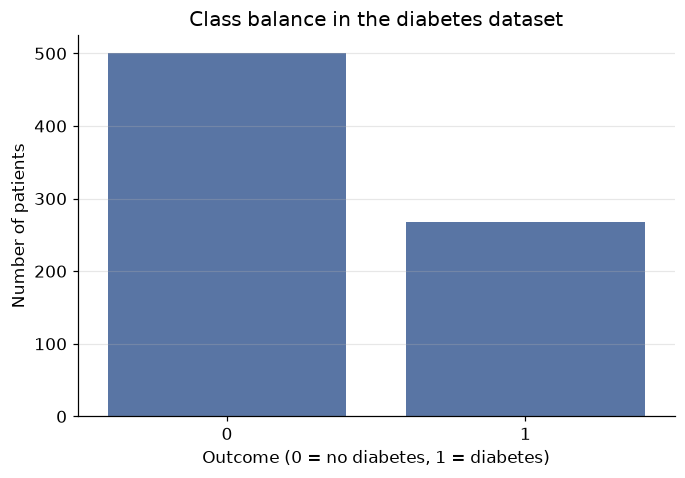

A 'model' that always predicts 0 would score 65.4% accuracy on our test set —
while detecting 0 of the 80 actual diabetes cases.


In [20]:
sns.countplot(x="Outcome", data=diabetes)
plt.title("Class balance in the diabetes dataset")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Number of patients")
plt.show()

lazy_accuracy = (y_test == 0).mean()
print(f"A 'model' that always predicts 0 would score {lazy_accuracy:.1%} accuracy on our test set —")
print(f"while detecting 0 of the {int((y_test == 1).sum())} actual diabetes cases.")

Two-to-one imbalance: enough that our model's headline accuracy deserves suspicion. The always-predict-0
baseline gets most of the way to our model's score *without learning anything*. We need metrics that
look at the two kinds of error separately.

### 9.4 Precision — "when it says yes, is it right?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

Of all patients the model *flagged* as diabetic, what fraction actually are? Precision is the metric to
watch when **false positives are expensive** — e.g. a spam filter (an FP buries a real email; better to
let some spam through than to trash a job offer).

In [21]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"→ Of the {tp + fp} patients flagged as diabetic, {precision:.1%} actually are. "
      f"The other {fp} are false alarms.")

Precision: 0.6173
→ Of the 81 patients flagged as diabetic, 61.7% actually are. The other 31 are false alarms.


### 9.5 Recall — "of the real yeses, how many did it find?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

Of all patients who *truly have* diabetes, what fraction did the model catch? (Also called *sensitivity*
or the *true positive rate*.) Recall is the metric to watch when **false negatives are expensive** —
disease screening, fraud detection: a miss means an untreated patient or an unnoticed theft.

In [22]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
print(f"→ Of the {tp + fn} patients who truly have diabetes, the model caught {recall:.1%}. "
      f"It sent {fn} home undiagnosed.")

Recall: 0.6250
→ Of the 80 patients who truly have diabetes, the model caught 62.5%. It sent 30 home undiagnosed.


For a *screening* tool, that recall is the number that should worry you — each miss is a person who walks
away believing they're healthy. And here's the tension: you can always buy more recall by flagging more
people (lower the 0.5 threshold), but every extra flag risks a false alarm, which *drains precision*. The
two metrics pull against each other — this is the **precision–recall trade-off**, and where you settle
depends on which error costs more in your problem.

### 9.6 F1 score — one number balancing both

When you need a single summary that respects the trade-off, take the **harmonic mean** of precision
and recall:

$$\text{F1} = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Why harmonic rather than ordinary mean? The harmonic mean is dragged toward the *smaller* value — a model
with precision 1.0 and recall 0.1 scores F1 ≈ 0.18, not 0.55. You cannot excel at F1 by gaming one metric
and ignoring the other.

In [23]:
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}\n")

# classification_report gathers everything in one table
print(classification_report(y_test, y_pred, target_names=["no diabetes (0)", "diabetes (1)"]))

F1 score: 0.6211

                 precision    recall  f1-score   support

no diabetes (0)       0.80      0.79      0.80       151
   diabetes (1)       0.62      0.62      0.62        80

       accuracy                           0.74       231
      macro avg       0.71      0.71      0.71       231
   weighted avg       0.74      0.74      0.74       231



The report shows all metrics *per class* — read the `diabetes (1)` row for the numbers we computed by hand.
The full picture: decent accuracy, moderate precision, and a recall that would be unacceptable for a real
screening tool. If you reported only accuracy, none of that nuance would surface. **Metric choice is a
modelling decision, not an afterthought** — decide which error is costlier *before* you evaluate.

---
## 10. Beyond two classes

Everything so far assumed two classes. But the world often offers more: ten handwritten digits, three iris
species, dozens of product categories. Look again at the right panel of Figure 1 — three clouds of points,
and no single S-curve can separate them. Three strategies exist, two of which cleverly recycle the binary
classifier we already have.

### 10.1 One-vs-Rest (OvR)

Split one $K$-class problem into $K$ binary problems. For classes A, B, C: train classifier 1 on
"A vs. not-A", classifier 2 on "B vs. not-B", classifier 3 on "C vs. not-C".

<div align="center">
<table>
<tr>
<td><img src="resources/images/ovr_class_a.png" width="330"></td>
<td><img src="resources/images/ovr_class_b.png" width="330"></td>
</tr>
<tr>
<td><img src="resources/images/ovr_class_c.png" width="330"></td>
<td><img src="resources/images/ovr_combined.png" width="330"></td>
</tr>
</table>

*Figure 6 — One-vs-Rest: three binary problems (A vs. rest, B vs. rest, C vs. rest), then combine.*
</div>

Each classifier $h_w^{(i)}(x)$ outputs the probability that $x$ belongs to *its* class. To classify a new
point, ask all $K$ classifiers and pick the most confident:

$$\hat{y} = \arg\max_i \; h_w^{(i)}(x)$$

**The catch:** each binary classifier trains on a lopsided view — for class A's classifier, the "rest"
pile is roughly $(K-1)$ times bigger than the "A" pile, even if the original classes were perfectly
balanced. With many classes, every sub-problem becomes an imbalanced one (and Section 9.3 told us what
that does).

### 10.2 One-vs-One (OvO)

Alternative: train a binary classifier for every *pair* of classes — A vs. B, A vs. C, B vs. C. For $N$
classes that's

$$\binom{N}{2} = \frac{N(N-1)}{2} \text{ classifiers}$$

(the handshake formula: every class shakes hands with every other once). To classify a new point, run all
of them and let them **vote**; the class collecting the most wins. Each sub-problem is small and balanced,
but the classifier count grows quadratically — 10 classes already need 45 models — and ties can leave the
vote ambiguous.

### 10.3 Softmax regression — the direct route

Rather than bolting binary classifiers together, generalize logistic regression itself. Give *each class
$k$ its own weight vector* $w_k$ and compute a per-class score for input $x$:

$$s_k(x) = w_k^T x$$

Then replace the sigmoid with the **softmax function** (a "normalized exponential"), which converts the
$K$ scores into $K$ probabilities that sum to 1:

$$\hat{P}_k = \text{softmax}(s(x))_k = \frac{e^{s_k(x)}}{\sum_{j=1}^{K} e^{s_j(x)}}$$

The exponential makes every term positive; the denominator normalizes. Prediction is again the class with
the highest probability: $\hat{y} = \arg\max_k \hat{P}_k$. For $K = 2$, softmax collapses exactly to the
sigmoid — logistic regression is just its special case.

### 10.4 Cross-entropy: the cost function, generalized

Training softmax regression needs a cost. Write the true label as a **one-hot vector** $y$ (a 1 in the
correct class's slot, 0 elsewhere) and the model's output as the probability vector $\hat{y}$. The
**cross-entropy** cost for one example is:

$$\text{Cost}(\hat{y}, y) = -\sum_{k=1}^{K} y_k \log(\hat{y}_k) = -\log(\hat{y}_c) \qquad (c = \text{the correct class})$$

— all terms with $y_k = 0$ vanish, leaving just the negative log-probability the model gave the *right*
answer. Confident and correct → cost near 0; confident and wrong → cost explodes. Averaged over $m$
examples it becomes $\mathcal{J}(W) = -\frac{1}{m}\sum_i \sum_k y_k^{(i)} \log \hat{y}_k^{(i)}$, and with
$K = 2$ it reduces to the binary cross-entropy of Equation 3.

The story completes the same way it did in Section 7: cross-entropy is convex, its gradient for each
class's weights is

$$\nabla_{w_k} \mathcal{J}(W) = \frac{1}{m}\sum_{i=1}^{m}\big(\hat{y}_k^{(i)} - y_k^{(i)}\big)\, x^{(i)}$$

— *(prediction − truth) × feature, averaged*, for the third time in three modules — and gradient descent
does the rest.

In scikit-learn, none of this needs new syntax. Hand `LogisticRegression` a multiclass target and it
quietly does softmax regression. Watch it on the classic iris dataset (three species, four flower
measurements):

In [24]:
iris = load_iris()
X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=RANDOM_STATE, stratify=iris.target)

softmax_reg = LogisticRegression(max_iter=1000)   # multiclass handled automatically (softmax)
softmax_reg.fit(X_ir_train, y_ir_train)

print(f"Test accuracy on 3-class iris: {softmax_reg.score(X_ir_test, y_ir_test):.1%}\n")

# Probabilities now come as one column per class — and each row still sums to 1
proba = softmax_reg.predict_proba(X_ir_test[:5])
print(pd.DataFrame(proba, columns=iris.target_names).round(3).assign(row_sum=proba.sum(axis=1)))

Test accuracy on 3-class iris: 93.3%

   setosa  versicolor  virginica  row_sum
0   0.000       0.032      0.968      1.0
1   0.005       0.764      0.232      1.0
2   0.001       0.506      0.493      1.0
3   0.005       0.662      0.333      1.0
4   0.002       0.410      0.589      1.0


Three columns now — one probability per species, summing to 1 in every row, exactly as softmax promises.
Same `fit`/`predict`/`predict_proba` you learned in Section 4; the two-class tool generalized without
changing its interface.

---
## 11. Your turn

Add cells below each exercise. Exercises 2 and 3 are the ones that consolidate the big ideas.

**Exercise 1 — Break the straight line.**
Return to the Section 2 setup and append one extra admitted student with a GRE score of 340 to the data.
Refit `LinearRegression` and re-plot. Where does the line's crossing of $y = 0.5$ move? Now refit
`LogisticRegression` on the same augmented data and plot its probability curve. Which model changed its
mind about the borderline students, and why?

**Exercise 2 — Move the threshold, move the trade-off.**
For the diabetes model, get probabilities with `logistic_diab.predict_proba(X_test)[:, 1]` and create
predictions at thresholds 0.3, 0.5, and 0.7 (e.g. `(proba >= 0.3).astype(int)`). Compute precision and
recall for each. Which threshold would you choose for a *screening* tool whose positives all receive a
cheap follow-up test — and which for an *automatic treatment* decision with serious side effects? Justify
using the error types.

**Exercise 3 — Beat the lazy baseline honestly.**
Compute the F1 score of the always-predict-0 baseline from Section 9.3 (careful: what are its TP and FP?)
and compare it with our model's F1. Then explain in two sentences why F1 exposes the lazy baseline while
accuracy flatters it.

**Exercise 4 — The suspicious zeros.**
In the diabetes data, replace the impossible zeros in `Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, and `BMI` with the column *median* (computed on the training split only!). Refit and re-evaluate.
Which metrics move, and in which direction?

**Exercise 5 — Iris, one species at a time.**
Fit `LogisticRegression(multi_class="ovr")` on the iris training data and compare its test accuracy and
`predict_proba` output with the softmax version from Section 10. Do the OvR probability rows still sum
exactly to 1? Explain what OvR does differently.

---
## 12. If you remember nothing else

1. **Classification predicts a discrete label; regression predicts a continuous value.** Fitting a straight
   line to 0/1 labels fails: impossible predictions outside $[0,1]$, poor fit, fragile cutoffs.

2. **Logistic regression = linear regression + sigmoid.** The model $p(x) = \sigma(w^T x)$ outputs the
   *probability* of the positive class; thresholding at 0.5 gives labels, and the set of points where
   $p(x) = 0.5$ is a *linear decision boundary*.

3. **The cost is binary cross-entropy, not SSE.** Squared error goes non-convex under the sigmoid; BCE
   $\big(-y\log h - (1-y)\log(1-h)$, averaged$\big)$ punishes confident mistakes brutally, has no
   closed-form solution, but is convex — so gradient descent finds the global minimum.

4. **The gradient is (prediction − truth) × feature, averaged** — the same form as linear regression's,
   and later softmax's. One update rule, three models.

5. **Never trust accuracy alone.** On imbalanced data a useless model scores high (the accuracy paradox).
   Read the confusion matrix; use **precision** when false positives are costly, **recall** when false
   negatives are costly, **F1** to balance both. Choosing the metric is part of modelling.

6. **Multiclass has three routes:** One-vs-Rest ($K$ binary models, imbalanced sub-problems), One-vs-One
   ($N(N-1)/2$ models, majority vote), and softmax regression (direct, with cross-entropy cost —
   the true generalization of logistic regression).

---
## 13. Further reading and glossary

### Further reading

- Aurélien Géron, *Hands-On Machine Learning with Scikit-Learn and TensorFlow* — Chapter 4 covers logistic
  and softmax regression; Chapter 3 is the definitive practical tour of classification metrics and the
  precision/recall trade-off.
- *An Introduction to Statistical Learning*, [Chapter 4](https://www.statlearning.com/) — classification,
  logistic regression, and why not linear regression, in full statistical dress.
- scikit-learn's guides to [logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
  and [classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).
- Jurafsky & Martin, [*Speech and Language Processing*, Chapter 5](https://web.stanford.edu/~jurafsky/slp3/) —
  a beautifully clear treatment of logistic regression, cross-entropy, and softmax.
- [Binary cross-entropy and logistic regression](https://towardsdatascience.com/binary-cross-entropy-and-logistic-regression-bf7098e75559) —
  including the proof that BCE is convex.

### Glossary

| Term | Meaning |
|---|---|
| **Classification** | Supervised learning where the target is a discrete class label |
| **Sigmoid** $\sigma(z)$ | $1/(1+e^{-z})$; squashes any real number into (0, 1) |
| **Decision boundary** | The surface where the model's predicted probability equals 0.5 |
| **Binary cross-entropy** | The convex log-loss cost minimized by logistic regression |
| **Confusion matrix** | 2×2 (or K×K) table of actual vs. predicted classes: TN, FP, FN, TP |
| **Type I / Type II error** | False positive / false negative |
| **Precision** | TP / (TP + FP) — reliability of the model's positive calls |
| **Recall (sensitivity)** | TP / (TP + FN) — coverage of the actual positives |
| **F1 score** | Harmonic mean of precision and recall |
| **Accuracy paradox** | High accuracy from a useless model on imbalanced classes |
| **One-vs-Rest / One-vs-One** | Multiclass via $K$ or $N(N-1)/2$ binary classifiers |
| **Softmax** | Generalized sigmoid: turns $K$ scores into $K$ probabilities summing to 1 |
| **Cross-entropy** | Generalized BCE: $-\log$ (probability assigned to the correct class) |